C:\Users\joenm\AppData\Local\Temp\ipykernel_25824\2930642086.py:33: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\joenm\AppData\Local\Temp\ipykernel_25824\2930642086.py:33: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

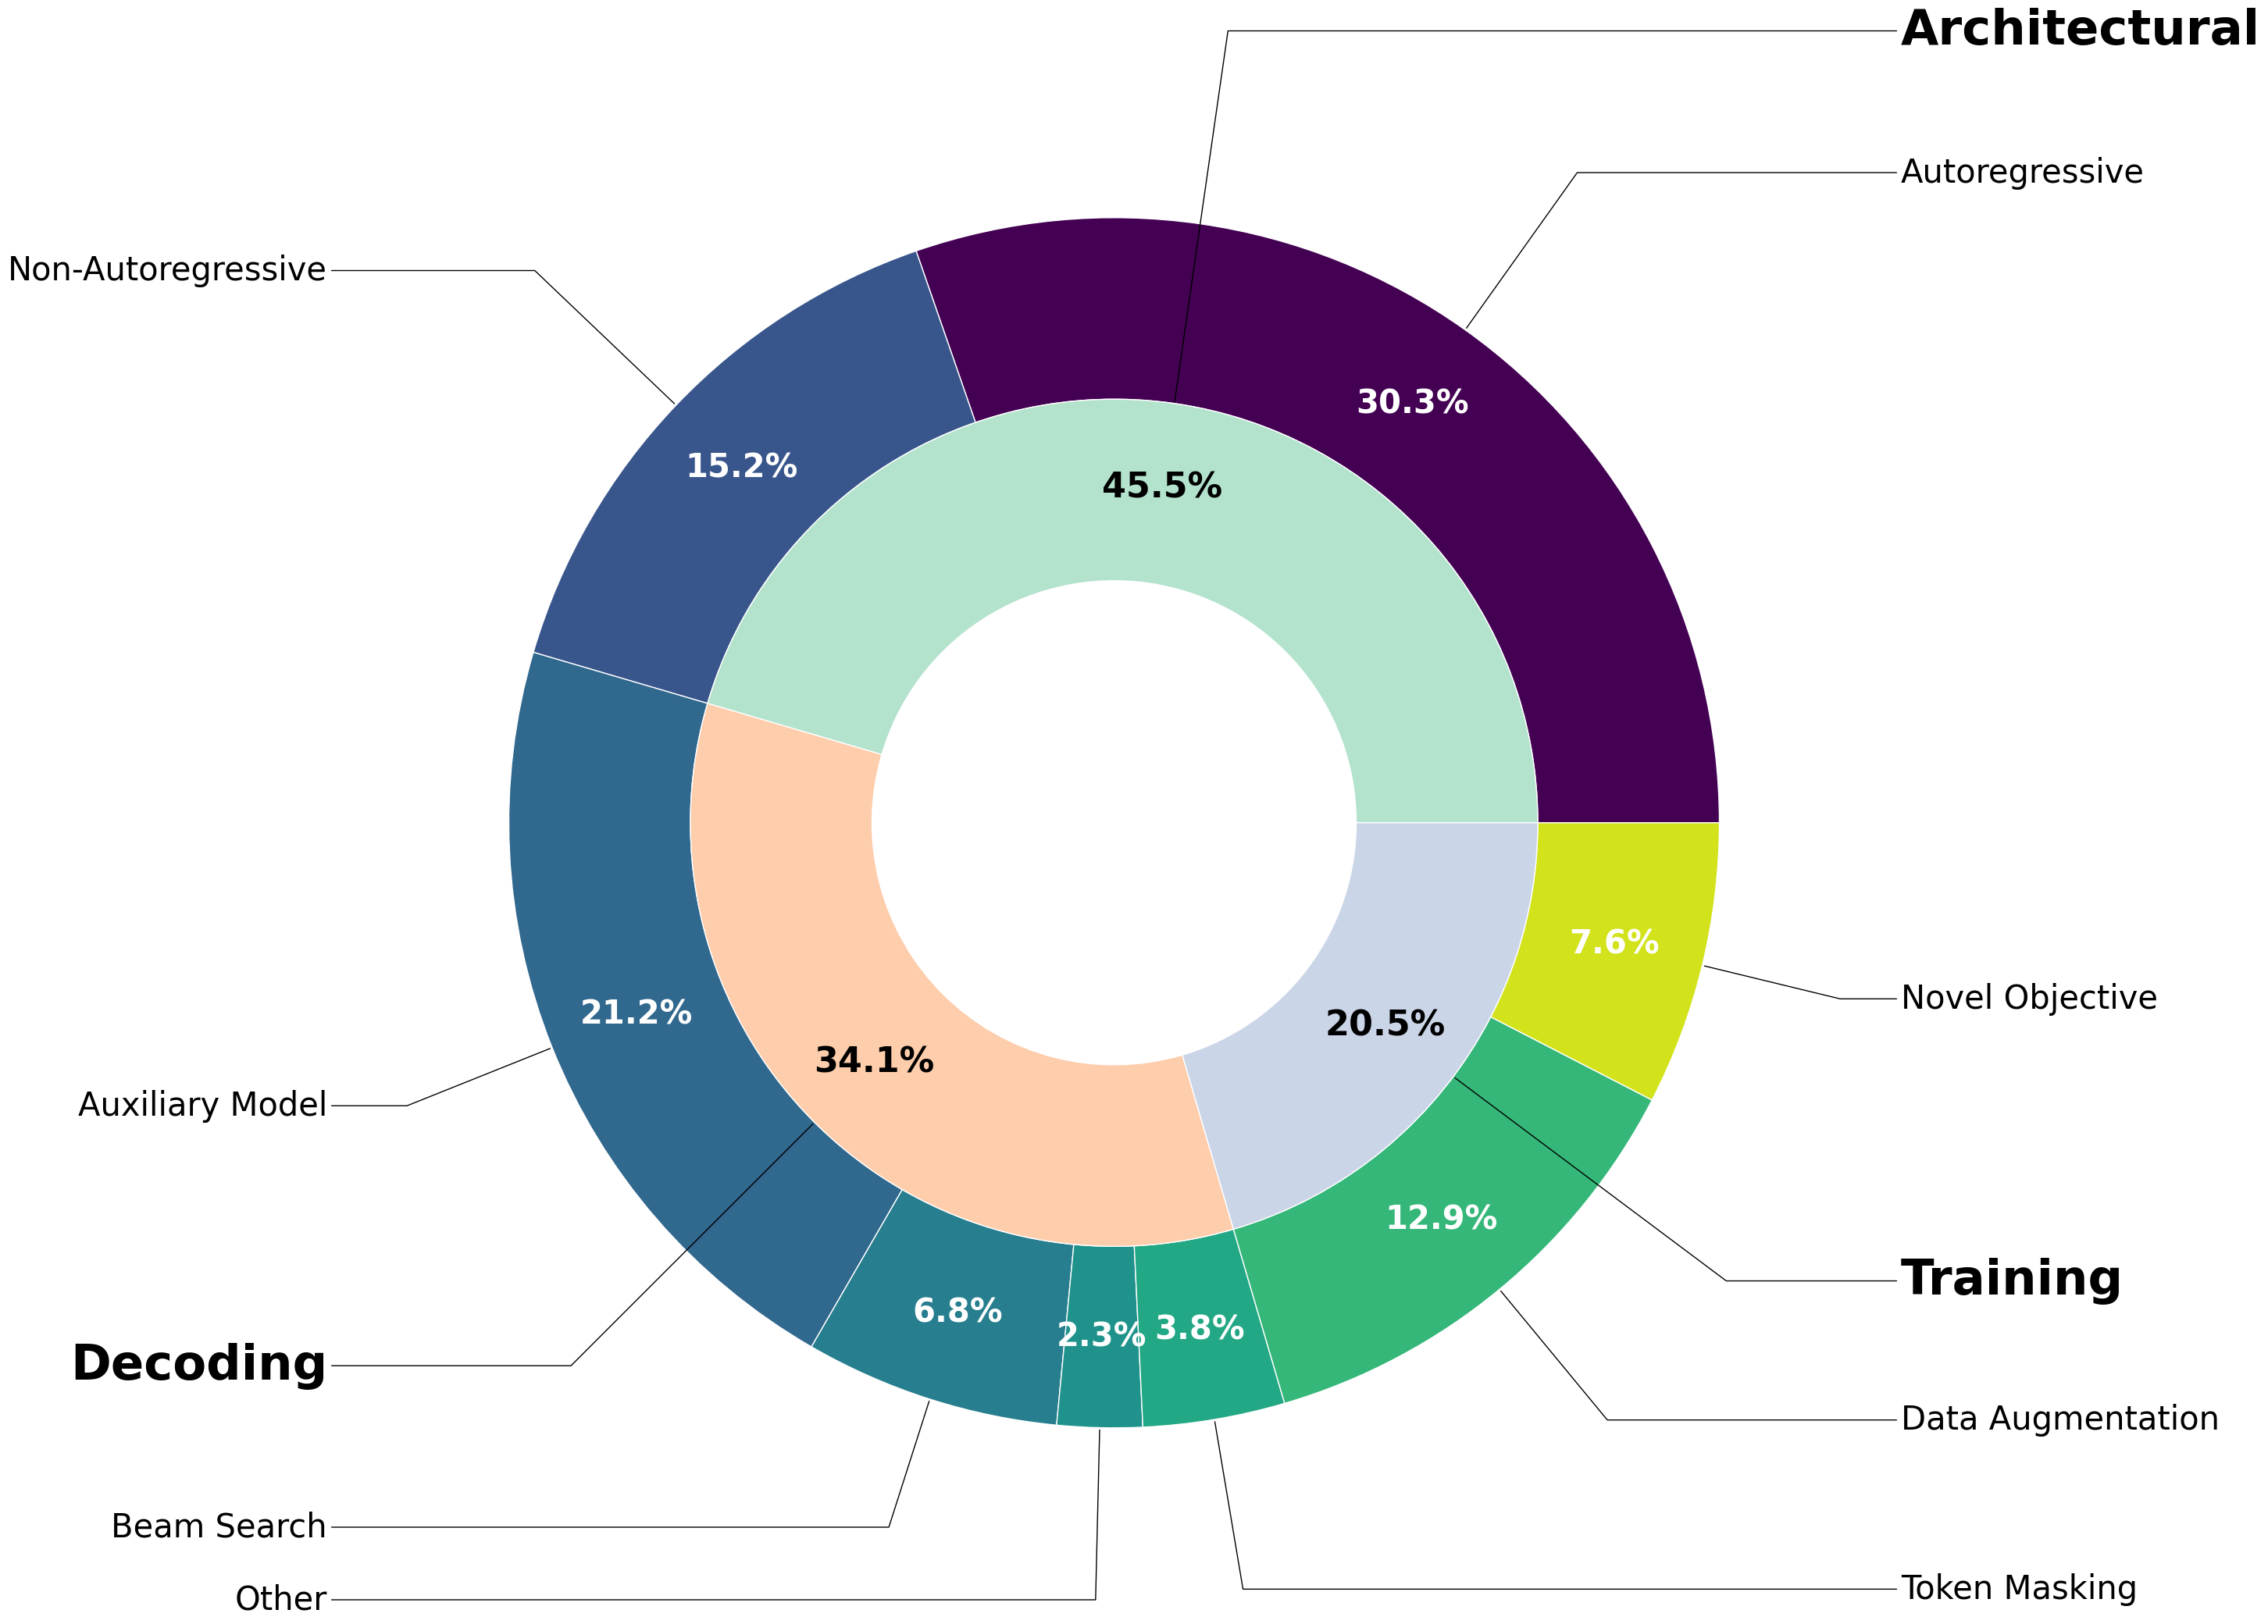

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set a nicer font
plt.rcParams['font.family'] = 'sans-serif'
# --- FONT STYLE SETTING ---
# You can change the font family for the labels here.
# For example, to use Times New Roman, you would change the list below to:
# plt.rcParams['font.sans-serif'] = ['Times New Roman', 'DejaVu Sans', 'Verdana']
plt.rcParams['font.sans-serif'] = ['Questrial', 'DejaVu Sans', 'Verdana'] 

# Load the dataset from the CSV file
try:
    df = pd.read_csv('final_taxonomy.csv')
except FileNotFoundError:
    print("The file 'final.csv' was not found in the current directory.")
    df = pd.DataFrame() # Create an empty dataframe to avoid further errors

if not df.empty:
    # --- Data Preparation ---
    
    # Filter for papers that are included in the review
    df_included = df[df['included in review'] == 'Y'].copy()

    # Clean up column names by removing leading/trailing whitespace
    df_included.columns = df_included.columns.str.strip()

    # Clean the 'General Method' and 'Specific Method' columns
    # Strip whitespace, and replace empty strings or NaN values with 'Unknown'
    for col in ['General Method', 'Specific Method']:
        df_included[col] = df_included[col].str.strip()
        df_included[col].fillna('Unknown', inplace=True)
        df_included.loc[df_included[col] == '', col] = 'Unknown'

    # --- Data Aggregation ---

    # Calculate the counts for each General Method
    general_counts = df_included['General Method'].value_counts().sort_index()

    # Calculate the counts for each Specific Method, grouped by General Method
    specific_counts = df_included.groupby(['General Method', 'Specific Method']).size().sort_index()

    # --- Plotting ---

    # Prepare data for the pie chart (General Method on the inside, Specific on the outside)
    outer_labels = specific_counts.index.get_level_values(1)
    outer_sizes = specific_counts.values
    inner_labels = general_counts.index
    inner_sizes = general_counts.values
    
    # Set up colors for the chart
    inner_cmap = plt.get_cmap('Pastel2')
    outer_cmap = plt.get_cmap('viridis')
    inner_colors = inner_cmap(np.arange(len(inner_labels)))
    
    # Generate grouped colors for the outer ring (Specific Methods)
    outer_colors = []
    num_specific_per_general = df_included.groupby('General Method')['Specific Method'].nunique().sort_index()
    
    color_group_idx = 0
    for i, method in enumerate(inner_labels): # Iterate through general methods for grouping
        num_specific = num_specific_per_general[method]
        color_group = outer_cmap(np.linspace(color_group_idx, color_group_idx + (1/len(inner_labels))*0.8, num_specific))
        outer_colors.extend(color_group)
        color_group_idx += 1/len(inner_labels)


    # Create the plot
    fig, ax = plt.subplots(figsize=(22, 22))

    # Plot the outer pie (Specific Method)
    # Hiding percentages for small slices to prevent overlap
    wedges_outer, _, autotexts_outer = ax.pie(outer_sizes, radius=1, labels=None, colors=outer_colors,
           wedgeprops=dict(width=0.3, edgecolor='w'), autopct=lambda p: f'{p:.1f}%' if p > 2 else '', pctdistance=0.85)

    # Plot the inner pie (General Method)
    wedges_inner, _, autotexts_inner = ax.pie(inner_sizes, radius=0.7, labels=None, colors=inner_colors,
           wedgeprops=dict(width=0.3, edgecolor='w'), autopct='%.1f%%', pctdistance=0.8)
    
    plt.setp(autotexts_outer, size=30, weight="bold", color="white")
    plt.setp(autotexts_inner, size=32, weight="bold", color="black")
    
    # --- Aligning Labels with Arrows ---
    
    # Common properties for annotations
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=10)
    arrow_props = dict(arrowstyle="-")

    # Helper function to add annotations
    def add_annotations(wedges, labels, radius, text_radius, ax, font_size, font_weight = None):
        items = []
        for i, p in enumerate(wedges):
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            items.append({'w': p, 'l': labels[i], 'a': ang, 'x': x, 'y': y})

        left = sorted([i for i in items if i['x'] < 0], key=lambda i: i['y'])
        right = sorted([i for i in items if i['x'] >= 0], key=lambda i: i['y'], reverse=True)

        min_sep = 0.12 # Minimum vertical separation

        # Adjust y-positions for right side (from top to bottom)
        if right:
            last_y = right[0]['y'] * text_radius
            right[0]['text_y'] = last_y
            for i in range(1, len(right)):
                y_pos = right[i]['y'] * text_radius
                if y_pos > last_y - min_sep:
                    y_pos = last_y - min_sep
                right[i]['text_y'] = y_pos
                last_y = y_pos

        # Adjust y-positions for left side (from bottom to top)
        if left:
            last_y = left[0]['y'] * text_radius
            left[0]['text_y'] = last_y
            for i in range(1, len(left)):
                y_pos = left[i]['y'] * text_radius
                if y_pos < last_y + min_sep:
                    y_pos = last_y + min_sep
                left[i]['text_y'] = y_pos
                last_y = y_pos
        
        # Draw the annotations
        for item in left + right:
            connectionstyle = f"angle,angleA=0,angleB={item['a']}"
            arrow_props.update({"connectionstyle": connectionstyle})
            ax.annotate(item['l'], 
                        xy=(radius * item['x'], radius * item['y']), 
                        xytext=(-text_radius, item['text_y']) if item['x'] < 0 else (text_radius, item['text_y']),
                        horizontalalignment='right' if item['x'] < 0 else 'left',
                        arrowprops=arrow_props,
                        fontsize=font_size,
                        fontweight=font_weight)

    # Add annotations for both charts
    add_annotations(wedges_inner, inner_labels, 0.7, 1.3, ax, 45, font_weight='bold')
    add_annotations(wedges_outer, outer_labels, 1, 1.3, ax, 30)
    
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    #fig.tight_layout()
    plt.show()


C:\Users\joenm\AppData\Local\Temp\ipykernel_25824\2026517724.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




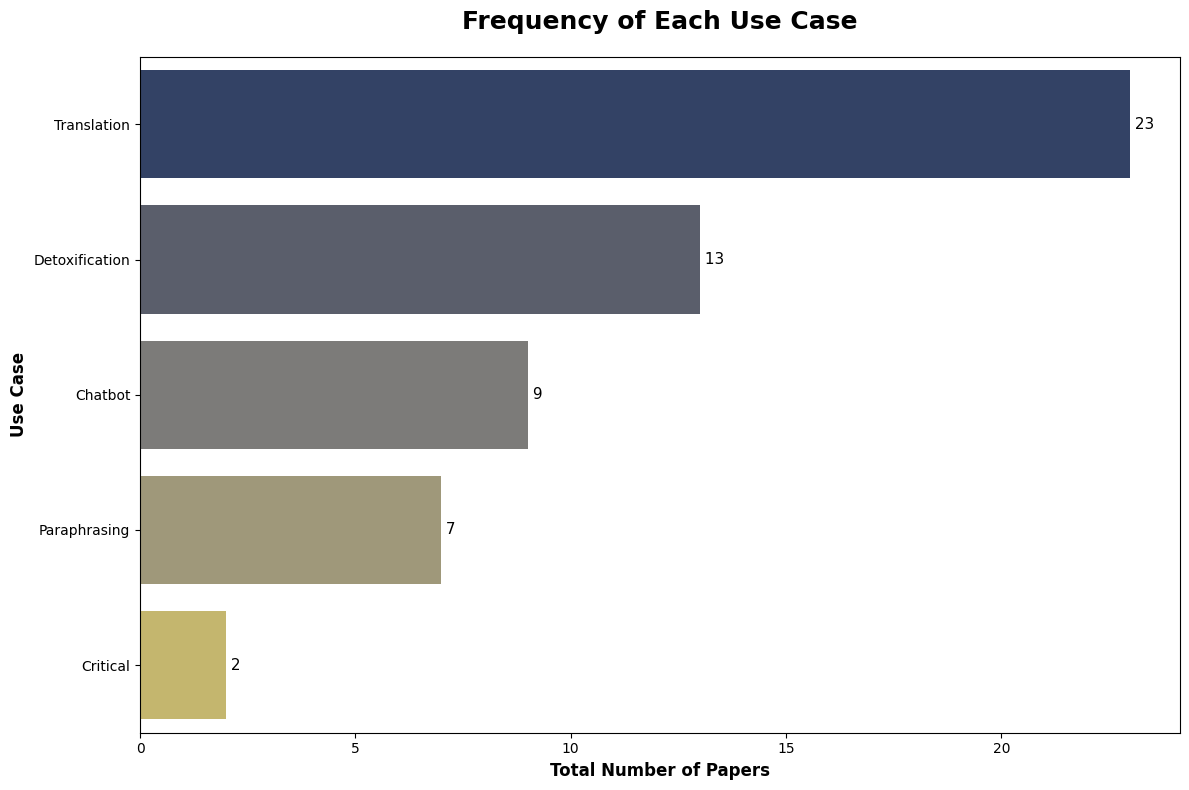

In [30]:
import seaborn as sns

# --- Bar Chart of Individual Use Case Frequencies ---

# Data preparation for this cell: create the boolean indicator matrix.
use_case_df = df_included[['Use case']].dropna().copy()
use_case_df = use_case_df[use_case_df['Use case'] != '']
use_case_indicators = use_case_df['Use case'].str.get_dummies(sep=' ')

# --- Data Calculation ---

# Calculate the total number of papers for each use case
use_case_totals = use_case_indicators.sum().sort_values(ascending=False)

# --- Plotting ---

plt.figure(figsize=(12, 8))
# Changed palette to 'pastel'
sns.barplot(x=use_case_totals.values, y=use_case_totals.index, palette='cividis')

# Add labels and title
plt.xlabel('Total Number of Papers', fontsize=12, weight='bold')
plt.ylabel('Use Case', fontsize=12, weight='bold')
plt.title('Frequency of Each Use Case', fontsize=18, weight='bold', pad=20)

# Add data labels to the end of the bars for clarity
for index, value in enumerate(use_case_totals):
    plt.text(value, index, f' {value}', va='center', fontsize=11)

plt.tight_layout()
plt.show()


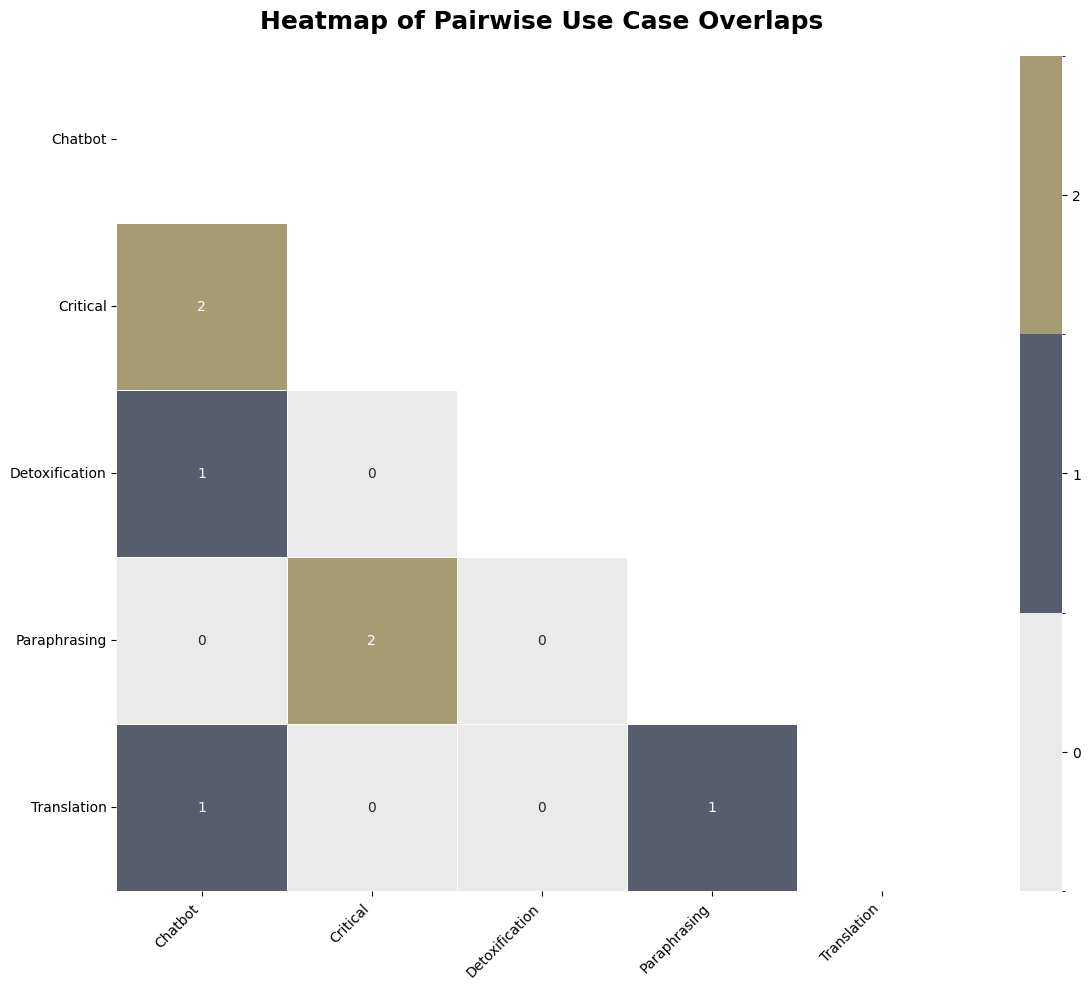

In [3]:
# --- Heatmap of Use Case Overlaps ---

# This heatmap shows the number of papers shared between any two use cases.
# The diagonal and upper triangle are masked to avoid redundancy and improve clarity.

# --- Data Preparation ---

# Data preparation for this cell: create the boolean indicator matrix.
use_case_df = df_included[['Use case']].dropna().copy()
use_case_df = use_case_df[use_case_df['Use case'] != '']
use_case_indicators = use_case_df['Use case'].str.get_dummies(sep=' ')

# We can calculate the overlap matrix by performing a dot product on the
# boolean indicator matrix with its transpose.
overlap_matrix = use_case_indicators.T.dot(use_case_indicators)

# Create a boolean mask for the upper triangle of the plot.
mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))

# --- Custom Colormap ---
from matplotlib.colors import ListedColormap, BoundaryNorm

# Find the maximum overlap value, ignoring the diagonal totals.
matrix_for_max = overlap_matrix.copy()
np.fill_diagonal(matrix_for_max.values, 0)
max_val = matrix_for_max.max().max()

# Create a custom list of colors.
# The first color is a neutral grey for cells with a value of 0.
# The rest of the colors are from a pastel palette for values 1, 2, 3, etc.
colors = ['#EAEAEA']  # A light grey for 0
palette = sns.color_palette("cividis", n_colors=max_val)
colors.extend(palette)

# Create the discrete colormap and a normalization instance.
# This ensures that each integer value gets a specific color from our list.
custom_cmap = ListedColormap(colors)
bounds = np.arange(-0.5, max_val + 1.5, 1)
norm = BoundaryNorm(bounds, custom_cmap.N)

# --- Plotting ---

plt.figure(figsize=(12, 10))
# Apply the mask and custom colormap. Note the `cbar_kws` to show integer ticks on the color bar.
sns.heatmap(
    overlap_matrix,
    mask=mask,
    annot=True,
    fmt='d',
    cmap=custom_cmap,
    norm=norm,
    linewidths=.5,
    cbar_kws={"ticks": np.arange(0, max_val + 1)}
)

# Add title and rotate axis labels for better readability
plt.title('Heatmap of Pairwise Use Case Overlaps', fontsize=18, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


C:\Users\joenm\AppData\Local\Temp\ipykernel_25824\551749246.py:14: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





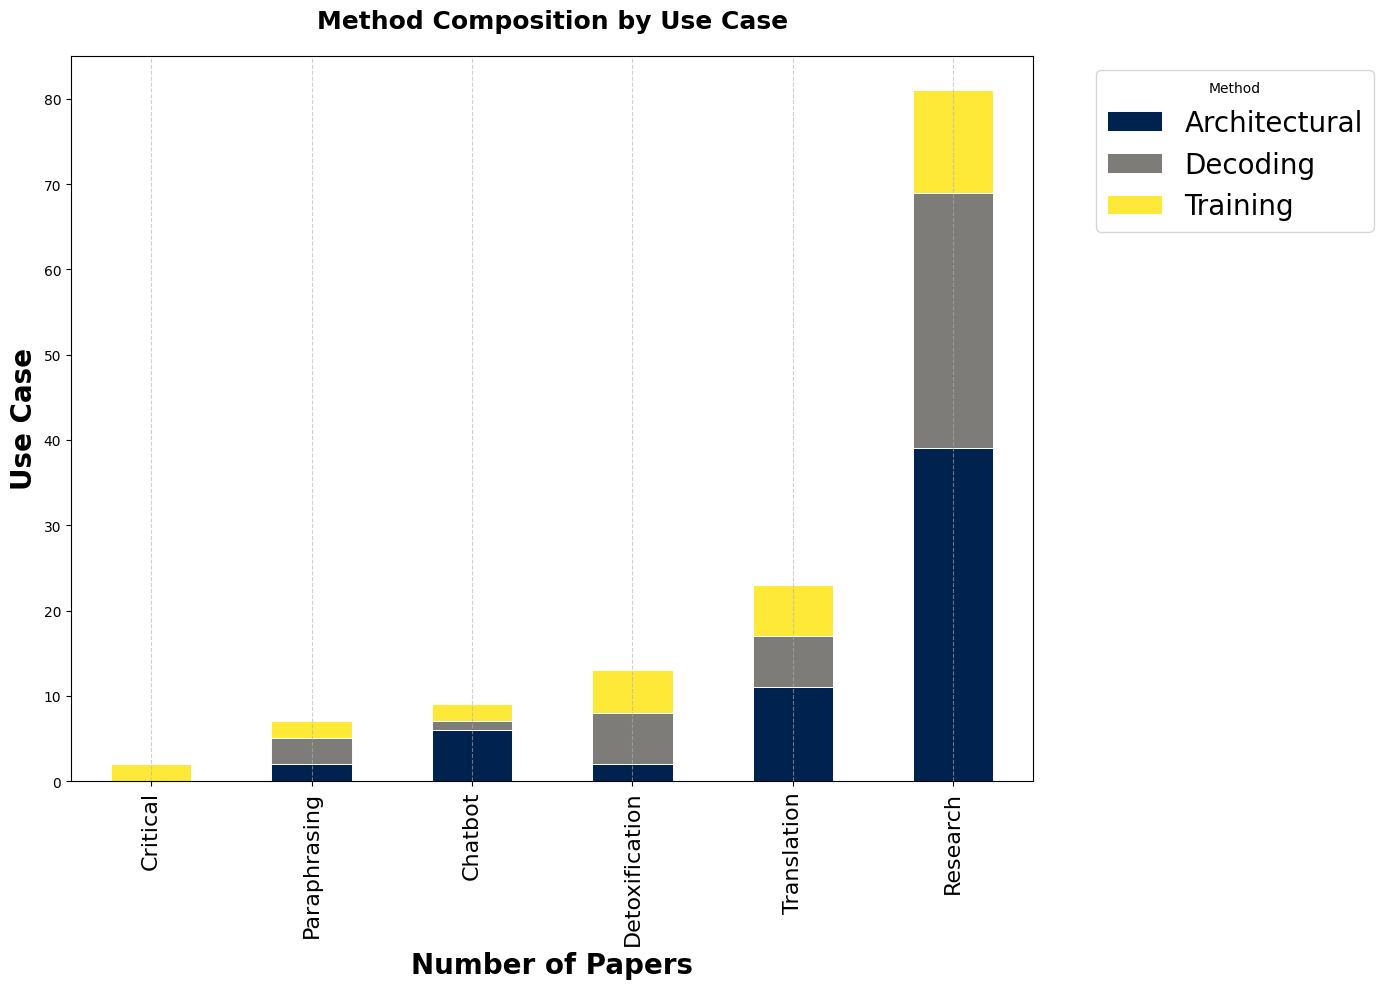

In [31]:
# --- Stacked Bar Chart of General Methods per Use Case ---

# This chart shows the distribution of General Methods for each individual Use Case.
# Each horizontal bar represents a Use Case, and its segments show the
# composition of papers by their General Method.

# --- Data Preparation ---

# 1. Start with a fresh copy of the relevant columns.
method_by_use_case_df = df_included[['Use case', 'General Method']].copy()

# 2. Handle missing/empty 'Use case' data by labeling it as 'Other'.
#    We also filter out papers with an 'Unknown' General Method.
method_by_use_case_df['Use case'].fillna('Other', inplace=True)
method_by_use_case_df.loc[method_by_use_case_df['Use case'] == 'Other', 'Use case'] = 'Research'
method_by_use_case_df = method_by_use_case_df[method_by_use_case_df['General Method'] != 'Unknown']

# 3. Unpack the multi-label 'Use case' column.
#    First, split the strings into lists of words.
method_by_use_case_df['Use case'] = method_by_use_case_df['Use case'].str.split()
#    Then, 'explode' the DataFrame to create a separate row for each use case.
exploded_df = method_by_use_case_df.explode('Use case')

# 4. Create a cross-tabulation to count General Methods per Use Case.
#    This creates a DataFrame perfectly suited for a stacked bar chart.
crosstab_df = pd.crosstab(exploded_df['Use case'], exploded_df['General Method'])

# 5. Sort the data for a cleaner plot.
#    We sort the bars by their total number of papers.
crosstab_df['total'] = crosstab_df.sum(axis=1)
crosstab_df = crosstab_df.sort_values('total', ascending=True).drop(columns='total')

# --- Plotting ---

# Use a colorblind-friendly palette
colors = plt.get_cmap('cividis')(np.linspace(0, 1, len(crosstab_df.columns)))

# Create the stacked horizontal bar chart
ax = crosstab_df.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 10),
    color=colors,
    edgecolor='white',
    linewidth=0.7
)

# --- Formatting the Chart ---

# Add labels and title
ax.set_xlabel('Number of Papers', fontsize=20, weight='bold')
ax.set_ylabel('Use Case', fontsize=20, weight='bold')
ax.set_title('Method Composition by Use Case', fontsize=18, weight='bold', pad=20)

# Customize the legend
ax.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)
ax.tick_params(axis='x', labelsize=16)

# Improve layout
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


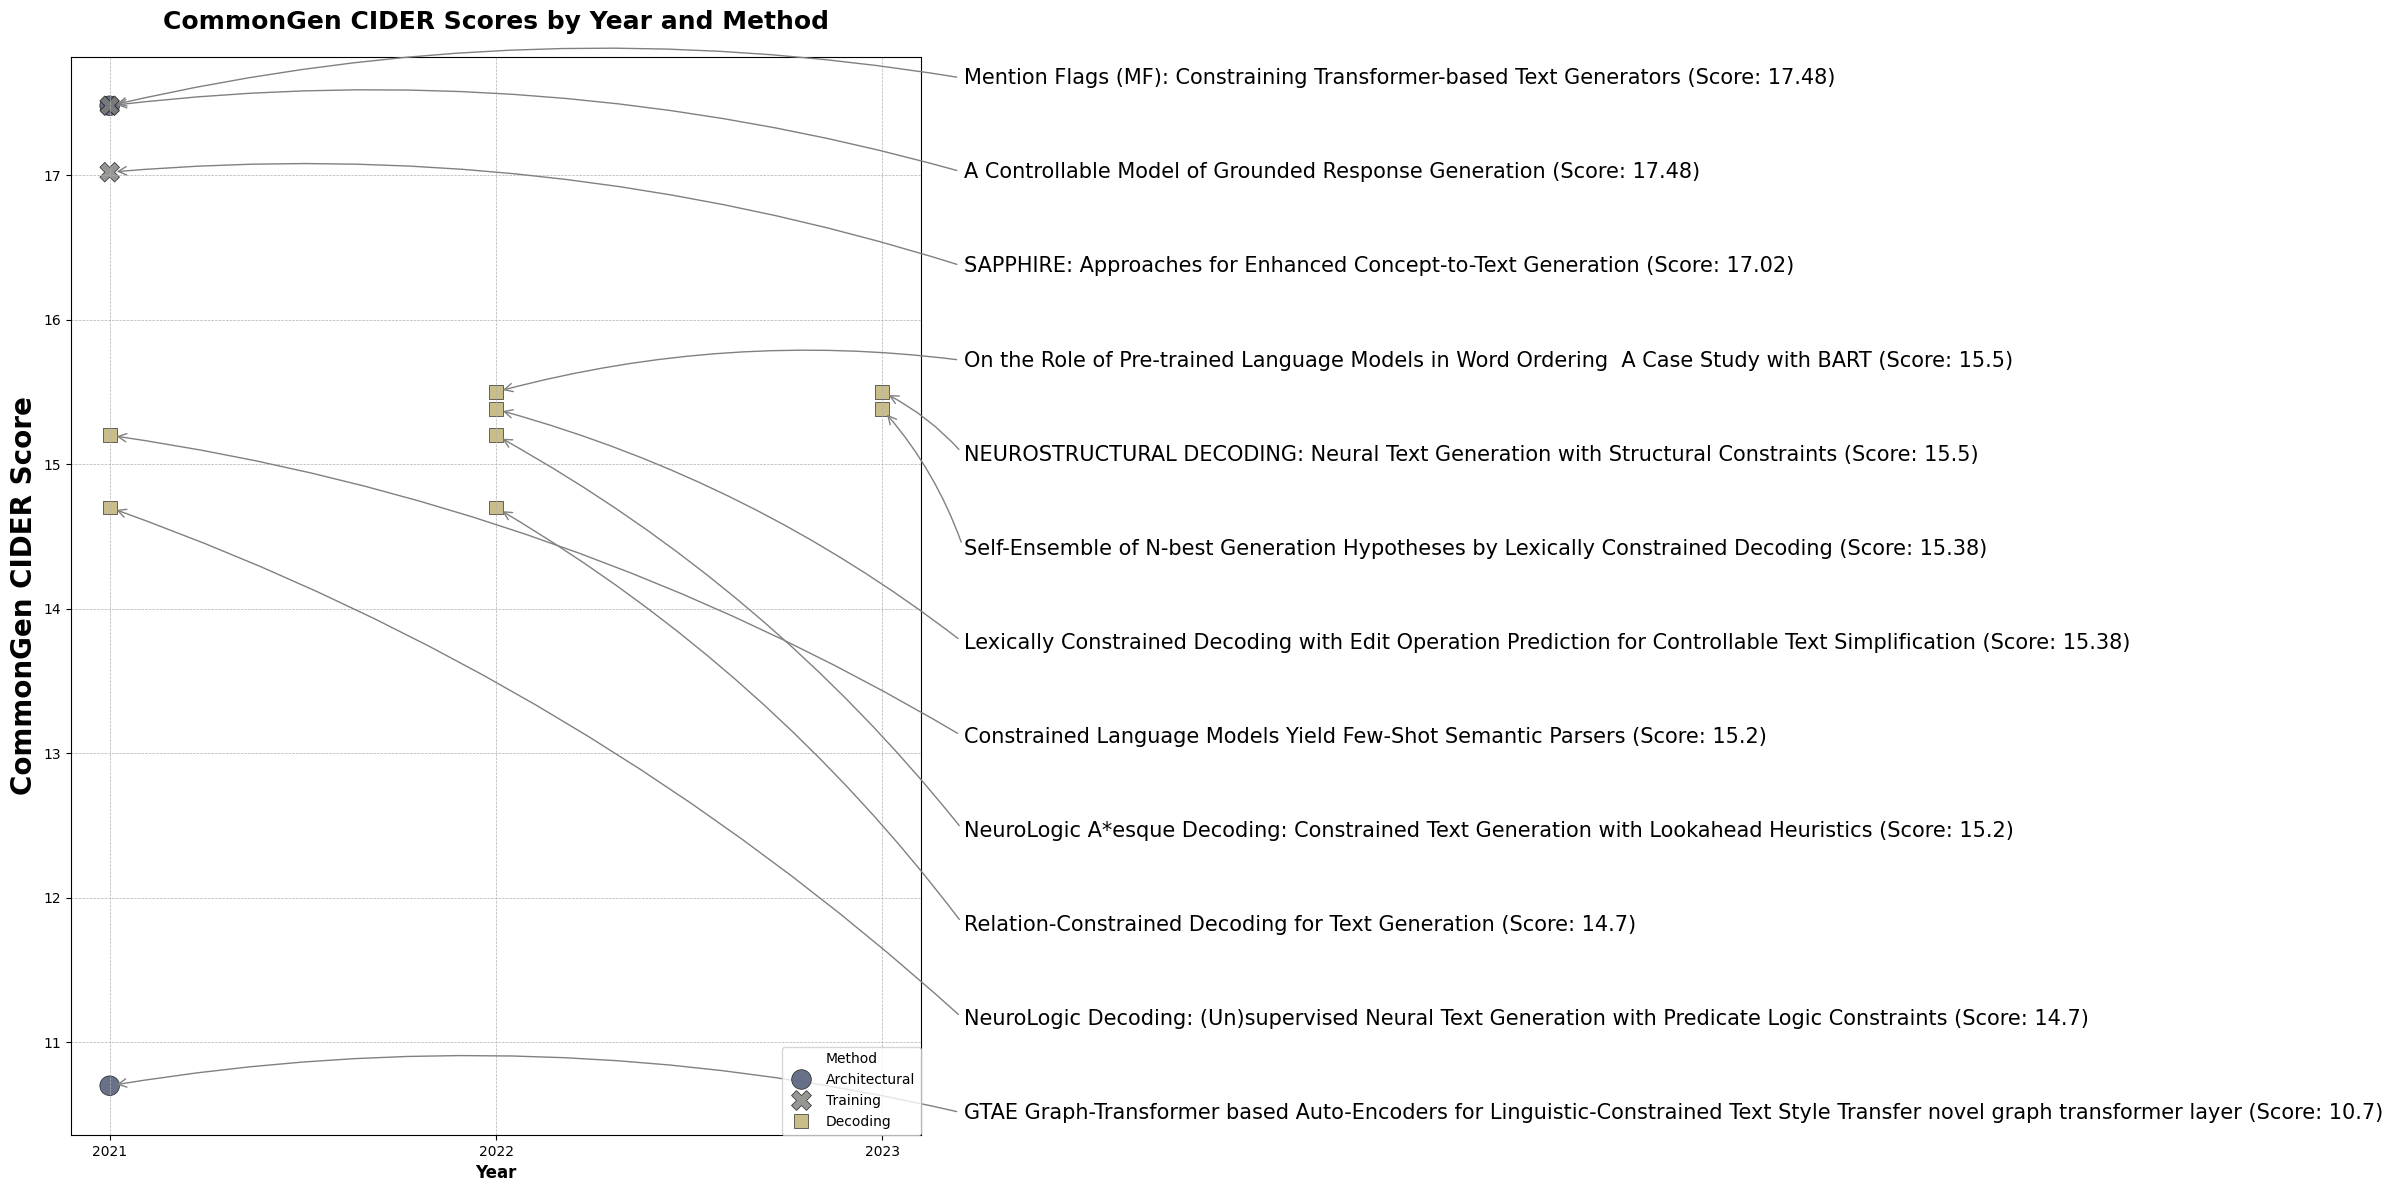

In [20]:
from matplotlib.ticker import MaxNLocator

# --- Scatter Plot with Non-Overlapping Side Labels (Improved) ---

# --- Data Preparation ---

# 1. Select relevant columns and drop rows with missing data.
cider_df = df_included[['year', 'CommonGen CIDER', 'title', 'General Method']].dropna().copy()
cider_df = cider_df[cider_df['CommonGen CIDER'] != '']
cider_df = cider_df[cider_df['General Method'] != 'Unknown']

# 2. Ensure data types are correct for plotting.
cider_df['year'] = pd.to_numeric(cider_df['year'])
cider_df['CommonGen CIDER'] = pd.to_numeric(cider_df['CommonGen CIDER'])

# 3. Sort by score. This helps make the connecting lines less tangled.
cider_df = cider_df.sort_values('CommonGen CIDER', ascending=False)


# --- Plotting ---
fig, ax = plt.subplots(figsize=(20, 14)) # Increased figure size for better spacing

# Create the scatter plot with the colorblind-friendly 'cividis' palette.
sns.scatterplot(
    data=cider_df,
    x='year',
    y='CommonGen CIDER',
    hue='General Method',
    style='General Method',
    palette='cividis', # Changed to a colorblind-friendly palette
    s=200,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# --- Add Side Labels with Pointers ---

# Create evenly spaced vertical positions for the labels on the right side.
num_labels = len(cider_df)
label_y_positions = np.linspace(0.98, 0.02, num_labels)
label_x_position = 1.05

# Add an annotation for each data point
for i, (_, row) in enumerate(cider_df.iterrows()):
    label = f"{row['title'].strip()} (Score: {row['CommonGen CIDER']})"
    
    ax.annotate(
        label,
        xy=(row['year'], row['CommonGen CIDER']),
        xycoords='data',
        xytext=(label_x_position, label_y_positions[i]),
        textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle="->",
            color="grey",
            shrinkA=5, shrinkB=5,
            patchA=None, patchB=None,
            connectionstyle="arc3,rad=0.1",
            relpos=(0, 0.5)  # Connect arrow to the left-center of the text box
        ),
        fontsize=15,
        ha='left',
        va='center'
    )

# --- Formatting the Chart ---
ax.set_title('CommonGen CIDER Scores by Year and Method', fontsize=18, weight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, weight='bold')
ax.set_ylabel('CommonGen CIDER Score', fontsize=20, weight='bold')

# Force integer ticks on the x-axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.setp(ax.get_xticklabels(), rotation=0)

# Adjust plot margins to make space for the labels
fig.subplots_adjust(right=0.55) # Adjusted margin for better fit

# Customize and move legend to the bottom-right
legend = ax.legend(
    title='Method',
    loc='best', # Moved to bottom-right
    #bbox_to_anchor=(label_x_position + 0.35, 0), # Position it neatly
    borderaxespad=0.
)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


In [15]:
import pandas as pd
import plotly.graph_objects as go
import glob
import numpy as np
import os
import plotly.colors
import re

def to_rgba_string(color_str, alpha=0.6):
    """
    Converts a color string (hex, rgb(...), or name) to a
    Plotly-compatible rgba string with a specified alpha.
    """
    # This function is designed to be robust to different color formats.
    if isinstance(color_str, str) and color_str.startswith('rgb'):
        # Handle the 'rgb(r, g, b)' format directly.
        return color_str.replace('rgb', 'rgba').replace(')', f', {alpha})')
    
    # For hex strings and color names, use Plotly's own robust converters.
    try:
        from matplotlib.colors import to_rgb
        rgb_tuple = tuple(int(c * 255) for c in to_rgb(color_str))
    except (ValueError, ImportError):
        # Fallback for any other unexpected color format
        try:
            rgb_tuple = plotly.colors.hex_to_rgb(color_str)
        except ValueError:
            return f"rgba(204, 204, 204, {alpha})" # Default to grey
            
    return f"rgba({rgb_tuple[0]}, {rgb_tuple[1]}, {rgb_tuple[2]}, {alpha})"

# --- 1. Calculate Source Data Sizes ---
sources = {
    "ACL": "**/acl_results.csv", "ACM": "**/*_acm*.csv", "DBLP": "**/*_dblp.csv",
    "OpenAlex": "**/*_openalex.csv", "Scopus": "**/*_scopus.csv", "IEEE": "**/*_ieee.csv"
}
source_counts = {}
for source, pattern in sources.items():
    count = 0
    files = glob.glob(pattern, recursive=True)
    for f in files:
        try:
            df = pd.read_csv(f)
            count += len(df)
        except Exception as e:
            print(f"Could not process file {f}: {e}")
    source_counts[source] = count

total_raw_count = sum(source_counts.values())

# --- 2. Load Final Dataset and Calculate Flows ---
try:
    final_df = pd.read_csv('final_taxonomy.csv')
    deduplicated_count = len(final_df)
    excluded_df = final_df[final_df['included in review'].astype(str).str.startswith('X')].copy()
    
    # --- Map exclusion reasons to new labels ---
    exclusion_label_map = {
        "X (P)": "Prompt Methods", "X (RAG)": "RAG Methods",
        "X (PR)": "Not Peer-Reviewed", "X (NR)": "Not Relevant"
    }
    excluded_df['included in review'] = excluded_df['included in review'].map(exclusion_label_map).fillna(excluded_df['included in review'])
    exclusion_counts = excluded_df['included in review'].value_counts().to_dict()
    
    # --- Sort exclusion reasons for consistent ordering ---
    sorted_exclusion_reasons = sorted(exclusion_counts.keys())
    
    included_df = final_df[final_df['included in review'].isin(['Y', 'Survey'])]
    included_count = len(included_df)

    # --- 3. Prepare Data for Sankey Diagram ---
    def style_label(label):
        # Wraps the label in an HTML span for styling.
        return f'<span style="font-family: Questrial, sans-serif; font-weight: bold; background-color: white; border: 1px solid black; padding: 3px; border-radius: 4px;">{label}</span>'

    node_labels_raw = {
        **{source: f"{source} ({count})" for source, count in source_counts.items()},
        "Combined": f"Combined Raw Data ({total_raw_count})",
        "DeduplicatedDataset": f"De-duplicated Dataset ({deduplicated_count})",
        **{reason: f"{reason} ({exclusion_counts[reason]})" for reason in sorted_exclusion_reasons},
        "Included": f"Included in Review ({included_count})"
    }
    
    labels = [style_label(l) for l in node_labels_raw.values()]
    label_indices = {name: i for i, name in enumerate(node_labels_raw.keys())}


    source_nodes, target_nodes, values = [], [], []
    
    # --- Define Flows ---
    combined_idx, deduplicated_idx = label_indices["Combined"], label_indices["DeduplicatedDataset"]
    for source in source_counts.keys():
        source_nodes.append(label_indices[source]); target_nodes.append(combined_idx); values.append(source_counts[source])
    
    source_nodes.append(combined_idx); target_nodes.append(deduplicated_idx); values.append(deduplicated_count)
    
    for reason in sorted_exclusion_reasons:
        source_nodes.append(deduplicated_idx); target_nodes.append(label_indices[reason]); values.append(exclusion_counts[reason])
        
    source_nodes.append(deduplicated_idx); target_nodes.append(label_indices["Included"]); values.append(included_count)

    # --- 4. Define Node Positions and Colors ---
    num_sources = len(source_counts)
    num_exclusions = len(sorted_exclusion_reasons)
    
    node_x = [0.01] * num_sources + [0.3, 0.6] + [0.8] * num_exclusions + [1.0]
    node_y = (list(np.linspace(0.01, 1, num_sources)) + [0.25, 0.75] + 
              list(np.linspace(0.01, 1, num_exclusions)) + [0.5])
    
    # --- Node Color Palette ---
    color_palette = plotly.colors.qualitative.Pastel[:num_sources]
    color_palette += ['#FFC107', '#FF9800']
    color_palette += ['#F44336'] * num_exclusions
    color_palette += ['#4CAF50']
    
    # --- Link Color Palette ---
    link_colors = []
    included_idx = label_indices["Included"]
    combined_idx = label_indices["Combined"]
    exclusion_indices = [label_indices[reason] for reason in sorted_exclusion_reasons]

    for source_node_idx, target_node_idx in zip(source_nodes, target_nodes):
        if target_node_idx == combined_idx:
            link_colors.append(to_rgba_string(color_palette[source_node_idx]))
        elif source_node_idx == combined_idx:
            link_colors.append(to_rgba_string(color_palette[target_node_idx]))
        elif target_node_idx == included_idx:
            link_colors.append(to_rgba_string('green'))
        elif target_node_idx in exclusion_indices:
            link_colors.append(to_rgba_string('red'))
        else:
            link_colors.append(to_rgba_string('lightgrey'))

    # --- 5. Create and Display the Sankey Diagram ---
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=25, thickness=20, line=dict(color="black", width=0.5),
            label=labels, x=node_x, y=node_y, color=color_palette
        ),
        link=dict(source=source_nodes, target=target_nodes, value=values, color=link_colors)
    )])
    
    fig.update_layout(
        title_text="Paper Gathering Process",
        font=dict(size=14, family="Questrial, sans-serif")
    )
    
    # --- 6. Save and Show ---
    fig.write_image("sankey_diagram.png", scale=2)
    print("Sankey diagram saved as 'sankey_diagram.png'")
    fig.show()

except FileNotFoundError:
    print("Error: 'final_taxonomy.csv' not found.")
except Exception as e:
    print(f"An error occurred: {e}")



Sankey diagram saved as 'sankey_diagram.png'


In [ ]:
import os
import pandas as pd
import glob

# Get the current working directory
CWD = os.getcwd()

# Define the sources and their filename patterns
sources = {
    "ACL": "**/acl_results.csv", 
    "ACM": "**/*_acm*.csv", 
    "DBLP": "**/*_dblp.csv",
    "OpenAlex": "**/*_openalex.csv", 
    "Scopus": "**/*_scopus.csv", 
    "IEEE": "**/*_ieee.csv"
}

# Find all subdirectories in the current directory, which represent the keywords
keywords = [d for d in os.listdir(CWD) if os.path.isdir(os.path.join(CWD, d)) and not d.startswith('.') and d != 'acl-anthology']

# --- Analysis ---
# Loop through each keyword (subdirectory) to count papers from each source
for keyword in keywords:
    print(f"--- Keyword: {keyword} ---")
    
    total_papers_for_keyword = 0
    
    # Get the counts for each source
    for source, pattern in sources.items():
        # Construct the full search path for the pattern within the keyword directory
        search_path = os.path.join(CWD, keyword, pattern)
        
        # Find all files matching the pattern
        files = glob.glob(search_path, recursive=True)
        
        # Sum up the number of papers from all files found for the current source
        count = 0
        for f in files:
            try:
                df = pd.read_csv(f)
                count += len(df)
            except Exception as e:
                print(f"Could not process file {f}: {e}")
                
        if count > 0:
            print(f"  \\item {source}: {count} papers")
            total_papers_for_keyword += count
            
    print(f"\\item  Total: {total_papers_for_keyword}\n")



--- Keyword: .git ---
\item  Total: 0

--- Keyword: acl-anthology ---
\item  Total: 0

--- Keyword: constrained text generation ---
  \item ACL: 16 papers
  \item ACM: 23 papers
  \item DBLP: 30 papers
  \item OpenAlex: 24 papers
  \item Scopus: 31 papers
\item  Total: 124

--- Keyword: controlled text generation ---
  \item ACL: 49 papers
  \item ACM: 56 papers
  \item DBLP: 30 papers
  \item OpenAlex: 100 papers
  \item Scopus: 87 papers
  \item IEEE: 8 papers
\item  Total: 330

--- Keyword: lexical constraints ---
  \item ACL: 26 papers
  \item ACM: 36 papers
  \item DBLP: 15 papers
  \item OpenAlex: 68 papers
  \item Scopus: 75 papers
  \item IEEE: 7 papers
\item  Total: 227



In [23]:
import os
import pandas as pd
import glob

# Get the current working directory
CWD = os.getcwd()

# Define the sources and their filename patterns
sources = {
    "ACL": "**/acl_results.csv", 
    "ACM": "**/*_acm*.csv", 
    "DBLP": "**/*_dblp.csv",
    "OpenAlex": "**/*_openalex.csv", 
    "Scopus": "**/*_scopus.csv", 
    "IEEE": "**/*_ieee.csv"
}

# Find all subdirectories in the current directory, which represent the keywords
# Exclude hidden directories like .git and acl-anthology
keywords = [d for d in os.listdir(CWD) if os.path.isdir(os.path.join(CWD, d)) and not d.startswith('.') and d != 'acl-anthology']

# --- Data Aggregation ---
# Create a DataFrame to store the counts
df_counts = pd.DataFrame(index=list(sources.keys()) + ['Total'], columns=keywords)

# Loop through each keyword and source to populate the DataFrame
for keyword in keywords:
    for source, pattern in sources.items():
        search_path = os.path.join(CWD, keyword, pattern)
        files = glob.glob(search_path, recursive=True)
        
        count = 0
        for f in files:
            try:
                df = pd.read_csv(f)
                count += len(df)
            except Exception as e:
                print(f"Could not process file {f}: {e}")
        
        df_counts.loc[source, keyword] = count

# Calculate the total for each keyword
df_counts.loc['Total'] = df_counts.sum()

# --- LaTeX Table Generation ---

# Fill any missing values with 0 and convert the DataFrame to integers
df_counts = df_counts.fillna(0).astype(int)

# Convert the DataFrame to a LaTeX table string
latex_table = df_counts.to_latex(caption="Data Gathering by Keyword")

print(latex_table)


\begin{table}
\caption{Data Gathering by Keyword}
\begin{tabular}{lrrr}
\toprule
 & constrained text generation & controlled text generation & lexical constraints \\
\midrule
ACL & 16 & 49 & 26 \\
ACM & 23 & 56 & 36 \\
DBLP & 30 & 30 & 15 \\
OpenAlex & 24 & 100 & 68 \\
Scopus & 31 & 87 & 75 \\
IEEE & 0 & 8 & 7 \\
Total & 124 & 330 & 227 \\
\bottomrule
\end{tabular}
\end{table}



C:\Users\joenm\AppData\Local\Temp\ipykernel_25824\1342898374.py:48: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

